# ECS7020P mini-project submission


## What is the problem?

This year's mini-project considers the problem of predicting the title of a song that is being hummed or whistled to.

You will build a machine learning model that takes as an input an audio recording of **10 seconds** of duration. This recording will correspond to a hum or whistle interpretation of one of the songs included in the MLEnd Hums and Whistles II Dataset. The output of the model will be the song label.


## Which dataset will I use?

We have created two subsets of the Hums and Whistles II Dataset. The first one has 400 samples (1.09GB). The second one has 800 samples (2.19 GB), including those already available in the first dataset.

You can download them from:

https://github.com/thekmannn/MLEndHW_Sample/raw/main/MLEndHWII_Sample_400.zip

and

https://github.com/thekmannn/MLEndHW_Sample/raw/main/MLEndHWII_Sample_800.zip





## What will I submit?

Your submission will consist of **one single Jupyter notebook** that should include:

*   **Text cells**, describing in your own words, rigorously and concisely your approach, each implemented step and the results that you obtain,
*   **Code cells**, implementing each step,
*   **Output cells**, i.e. the output from each code cell,

Your notebook **should have the structure** outlined below. Please make sure that you **run all the cells** and that the **output cells are saved** before submission.

Please save your notebook as:

* ECS7020P_miniproject_2526.ipynb


## How will my submission be evaluated?

This submission is worth 16 marks. We will value:

*   Conciseness in your writing.
*   Correctness in your methodology.
*   Correctness in your analysis and conclusions.
*   Completeness.
*   Originality and efforts to try something new.

**The final performance of your solutions will not influence your grade**. We will grade your understanding. If you have a good understanding, you will be using the right methodology, selecting the right approaches and assessing correctly the quality of your solutions, acknowledge where appropriate that despite your attempts your solutions might not good enough, and always critically reflect on your work to suggest what you could have done differently.

Note that **the problem that we are intending to solve is very difficult**. Do not despair if you do not get good results, **difficulty is precisely what makes it interesting** and **worth trying**.

## Show the world what you can do

Why don't you use **GitHub** to manage your project? GitHub can be used as a presentation card that showcases what you have done and gives evidence of your data science skills, knowledge and experience. **Potential employers are always looking for this kind of evidence**.





-------------------------------------- PLEASE USE THE STRUCTURE BELOW THIS LINE --------------------------------------------

# [Hums and Whistles II Dataset]

# 1 Author

**Student Name**:  Shamsa Abdulkadir Sheikh Mao

**Student ID**:  260151003



# 2 Problem formulation

Describe the machine learning problem that you want to solve and explain what's interesting about it.

## Answer

The machine learning problem I aim to solve in this project is predicting the title of a song in which an individual has hummed or whistled to for a 10 second duration.

During our week 4 lecture on classification, it was stated that classification problems build models that create a label when it is given several predictors. For this project the predictors are MFCC features and Chroma Features, which will be taken from the recordings, and the label will be the title of the song. Bishop et al. (2006) defined supervised learning problems as an application where the training data consists of input vectors and matching target vectors. Similarly, in this project we are looking at a supervised multi class classification problem where the input is an audio and the output is the title of the song.

An interesting element of the problem is the use of human interpretations through whistling and humming rather than instrumentation. The problem we are solving focuses mainly on the participants melody, which makes this difficult yet fascinating. This problem uses a similar approach to Query by Humming (QBH), where users whistled and hummed to fragments of music in order to retrieve songs and complete audio recordings (Dannenberg et al., 2004).
  

# 3 Methodology

Describe your methodology. Specifically, describe your training task and validation task, and how model performance is defined (i.e. accuracy, confusion matrix, etc). Any other tasks that might help you build your model should also be described here.

## Answer

I have identified the task in this mini project as a multi class classification problem. This is because a 10 second audio recording was converted into a fixed numerical form allowing the training data set of the ML model to predict the title of the song. Similarly, this approach was used in a multi class audio classification algorithm where several audio clips were taken from a movie in order to detect violent content. A key differentiation in this study and my approach is the sample size as they used a higher data test of 5000 clips where as I only used 400 samples (Giannakopoulos et al., 2007).

The methodology in my approach consists of three pipelines. As seen in section 4, each pipeline begins with the raw audio. After this I used the audio extraction features MFCC (Mel Frequency Cepstral Coefficients) and Chroma. MFCC is commonly used in audio recognition, in my case I have used MFCC to detect spectral content. A historic example of this is the study of parametric representation for monosyllabic speech recognition, resulting in a 95 % and 96% recognition with the use of MFCC in short term speech (Davis et al., 1980). Chroma is another feature extraction used in my approach as it focuses on the pitch of our sample audio. In the study of chroma toolbox with the implementation of MATLAB, it was stated that chroma is a significantly powerful feature for identifying songs and audio matching (Muller et al., 2011).

The classifiers I have used to train the model is SVM (Support Vector Machines) and Logistic Regression. Support Vector Machine (SVM) is suitable for high dimension feature areas and small datasets (Cortes et al., 1995). Logistic regression uses probability to determine if a class belongs to a certain input. This is a commonly use baseline feature, an example is the study of tagging music with logistic regression allowing the authors to use linear classifiers to recover tasks and music annotations (Xie et al., 2011).

I used a stratified train and validation split for this classification problem. I used a 70/30 stratification split meaning 70% of the samples were used for training and the remaining 30% of samples were used for validation. One key limitation I noticed here is that although this is standard split it can impact the validity of my results as some examples are left out of the training set and some examples are left out of the validation sets.

In addition to the constructed pipelines, the model uses accuracy and the confusion matrix to define it’s performance. I used accuracy in my approach as it allows us to see the performance of the model and presents which classifiers are correct in my sample. The confusion matrix also allows us to view the performance but in a different approach, as it identifies which songs are being mislabelled for one another and how frequently this mislabel occurs.

In [ ]:
#!pip install librosa

In [ ]:
import os
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    top_k_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

In [ ]:
extract_path = "MLEndHWII_sample_400"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# 4 Implemented ML prediction pipelines

Describe the ML prediction pipelines that you will explore. Clearly identify their input and output, stages and format of the intermediate data structures moving from one stage to the next. It's up to you to decide which stages to include in your pipeline. After providing an overview, describe in more detail each one of the stages that you have included in their corresponding subsections (i.e. 4.1 Transformation stage, 4.2 Model stage, 4.3 Ensemble stage).

## Answer
As you can see below i constructed three machine learning pipelines. The first stage is the input, which is the raw audio from the 400 samples file. The second stage is the feature extractions, MFCC and Chroma. The next stage is our classifiers, Logistic Regression and SVM (Support Vector Machine). Lastly, the output is what the model predicts to be the songs label. My pipeline uses a diverse set of classes and features, as the aim is to learn and compare the aspects of the data.

Pipeline A:

Audio + MFCC features + Logistic Regression + song label

Pipeline B:

Audio + MFCC features + SVM + song label

Pipeline C:  

Audio + Chroma features + SVM + song label

## 4.1 Transformation stage

Describe any transformations, such as feature extraction. Identify input and output. Explain why you have chosen this transformation stage.

### Answer

In this classification problem the input is the raw audio’s from the 400 samples data file and the output is the song label. I have changed the raw 10 second audio sample into a fixed length numerical vector. The second aspect of the transformation stage is the use of extraction feature, in this case MFCC and Chroma. Chroma is used to presents the pitch in the humming and whistling sample where are the MFCC creates an abstract of the spectral features.

To have a fixed length in my model I used statistics to summarise each feature, specifically the standard deviation and mean where used. This can be seen in Dataset B Audio Visualisation:

 feature_matrix.mean(axis=1),
 feature_matrix.std(axis=1)

## 4.2 Model stage

Describe the ML model(s) that you will build. Explain why you have chosen them.

### Answer
I implemented two machine learning models to my approach. Firstly, Logistic Regression was used as a baseline model. This is commonly used in audio recognition problems as it gives us a sufficient reference point. SVM (Support Vector Machine) was used as it creates non linear decisions, which benefits my model as the comparison between the title of the song and audio sample may not always be fully linear.

## 4.3 Ensemble stage

Describe any ensemble approach you might have included. Explain why you have chosen them.

### Answer
I explored a basic soft ensemble in addition to the pipelines were the highest average probability was taken as the final prediction however after finalising my pipeline there was no justification to include this as the sample was quite small for this method. As you can see in data set c when building the feature matrices, I also implemented a combined feature and Mel spectrogram as features and random forest as a classifier. However, similarly to the soft ensemble incorporating these additional pipelines did not suit the sample size. Also, MFCC is derived from Mel spectrogram, allowing the model to capture aspects from both features in one (Davis et al., 1980).

# 5 Dataset

Describe the datasets that you will create to build and evaluate your models. Your datasets need to be based on our MLEnd Hums and Whistles II Dataset. After describing the datasets, build them here. You can explore and visualise the datasets here as well.

If you are building separate training and validatio datasets, do it here. Explain clearly how you are building such datasets, how you are ensuring that they serve their purpose (i.e. they are independent and consist of IID samples) and any limitations you might think of. It is always important to identify any limitations as early as possible. The scope and validity of your conclusions will depend on your ability to understand the limitations of your approach.

If you are exploring different datasets, create different subsections for each dataset and give them a name (e.g. 5.1 Dataset A, 5.2 Dataset B, 5.3 Dataset 5.3) .

## Answer

An ML models performance counts on the data, errors or missing values in data can impact the validity of the results (Pierre et al., 2024). In this project I used the MLEnd Hums and Whistles II dataset, specifically the 400 sample set. The sample contains a 10 second audio of participants whistling and humming to different songs. The folder format was followed in order for each file to match the song label. Using a stratified sampling a training and validation split of 70/30 was made, this is so the class stays almost the same in both subsets.

Dhurandhar (2013) states that ML models predict all data is independently and identically distributed data (i.i.d). However, in this case the training and validation sets may use several recording from the same person. This presents a limitation in my approach as incorporating an 70/30 split can cause overrepresentation in performance and not considering the i.i.d approach can decrease my results validity.

Datasets overview:

Dataset A: Class Distribution

This subsection presents the number of samples per song. As shown in the graph the working datasets class distribution is plotted. This dataset is crucial as any disparities in class can impact the accuracy of both the interpretation and training.

Dataset B: Audio Visualisation

This subsection focuses on visualising the data through two samples mel spectrogram and waveform. Both examples used librosa before the feature extraction stage. This Python library was used as its main objective is to process audio and music signals, allowing a smooth transition for music information retrieval (MIR) (McFee et al., 2015).

Dataset C: Training and Validation

In this subsection a stratification of 70/30 was used to create the validation and training datasets. This is seen below where training samples is 280 and validation sample is 120. This stratification approach ensures an equal comparison in the three pipelines.

Please see below for each datasets results.

In [ ]:
DATASET_ROOT = "MLEndHWII_sample_400"
AUDIO_EXTENSIONS = {".wav"}

def infer_label_from_path(path: Path, dataset_root: str):
    return path.stem.split("_")[-1]

rows = []
for root, _, files in os.walk(DATASET_ROOT):
    for file_name in files:
        file_path = Path(root) / file_name
        if file_path.suffix.lower() in AUDIO_EXTENSIONS:
            label = infer_label_from_path(file_path, DATASET_ROOT)
            rows.append({
                "path": str(file_path),
                "label": label,
                "filename": file_name
            })

df = pd.DataFrame(rows)
print("Number of samples found:", len(df))
df.head()

Number of samples found: 400


,path,label,filename
0,MLEndHWII_sample_400/S70_hum_3_Friend.wav,Friend,S70_hum_3_Friend.wav
1,MLEndHWII_sample_400/S114_whistle_1_Friend.wav,Friend,S114_whistle_1_Friend.wav
2,MLEndHWII_sample_400/S118_hum_2_RememberMe.wav,RememberMe,S118_hum_2_RememberMe.wav
3,MLEndHWII_sample_400/S53_whistle_2_Feeling.wav,Feeling,S53_whistle_2_Feeling.wav
4,MLEndHWII_sample_400/S111_whistle_2_TryEveryth...,TryEverything,S111_whistle_2_TryEverything.wav


### 5.1 Dataset A: Class Distribution


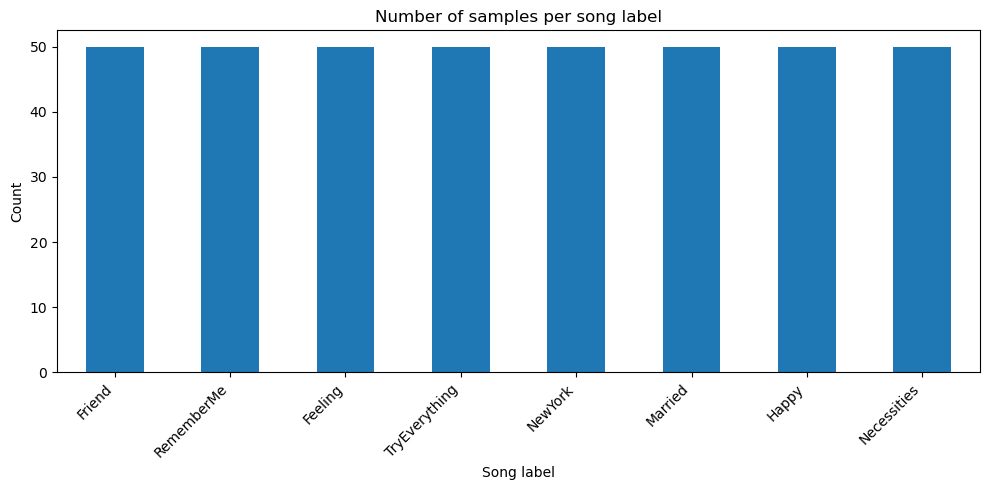

In [ ]:
label_counts = df["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Number of samples per song label")
plt.xlabel("Song label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.2 Dataset B: Audio Visualisation



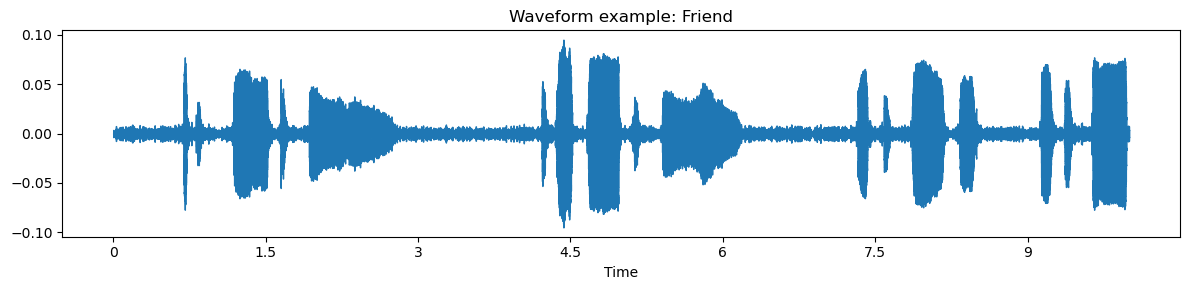

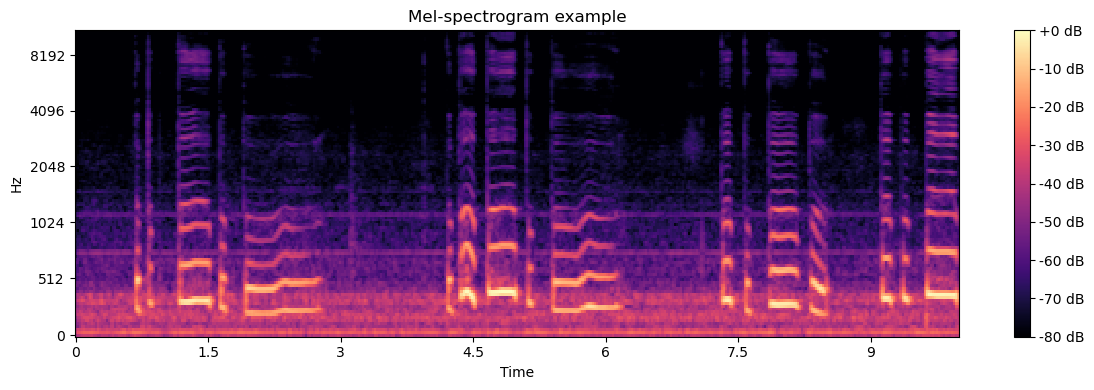

In [ ]:
sample_index = 0
sample_path = df.iloc[sample_index]["path"]
sample_label = df.iloc[sample_index]["label"]

y, sr = librosa.load(sample_path, sr=22050, duration=10.0)

plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform example: {sample_label}")
plt.tight_layout()
plt.show()

S = librosa.feature.melspectrogram(y=y, sr=sr)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-spectrogram example")
plt.tight_layout()
plt.show()

In [ ]:
def load_audio(file_path, sr=22050, duration=10.0):
    y, sr = librosa.load(file_path, sr=sr, duration=duration)

    target_length = int(sr * duration)

    if len(y) == 0:
        y = np.zeros(target_length)

    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))
    else:
        y = y[:target_length]

    max_abs = np.max(np.abs(y))
    if max_abs > 0:
        y = y / max_abs

    return y, sr

def summarise_feature_matrix(feature_matrix):
    return np.concatenate([
        feature_matrix.mean(axis=1),
        feature_matrix.std(axis=1)
    ])

def extract_mfcc_features(file_path, sr=22050, duration=10.0, n_mfcc=20):
    y, sr = load_audio(file_path, sr=sr, duration=duration)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    return np.concatenate([
        summarise_feature_matrix(mfcc),
        summarise_feature_matrix(delta),
        summarise_feature_matrix(delta2)
    ])

def extract_chroma_features(file_path, sr=22050, duration=10.0):
    y, sr = load_audio(file_path, sr=sr, duration=duration)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    return summarise_feature_matrix(chroma)

def extract_mel_features(file_path, sr=22050, duration=10.0, n_mels=64):
    y, sr = load_audio(file_path, sr=sr, duration=duration)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return summarise_feature_matrix(mel_db)

def extract_combined_features(file_path, sr=22050, duration=10.0):
    y, sr = load_audio(file_path, sr=sr, duration=duration)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    return np.concatenate([
        summarise_feature_matrix(mfcc),
        summarise_feature_matrix(chroma),
        summarise_feature_matrix(mel_db),
        summarise_feature_matrix(zcr),
        summarise_feature_matrix(centroid),
        summarise_feature_matrix(bandwidth),
        summarise_feature_matrix(rolloff)
    ])

### Feature Matrices

In [ ]:
X_mfcc = np.vstack(df["path"].apply(extract_mfcc_features).values)
X_chroma = np.vstack(df["path"].apply(extract_chroma_features).values)
X_mel = np.vstack(df["path"].apply(extract_mel_features).values)
X_combined = np.vstack(df["path"].apply(extract_combined_features).values)

print("MFCC feature shape:", X_mfcc.shape)
print("Chroma feature shape:", X_chroma.shape)
print("Mel feature shape:", X_mel.shape)
print("Combined feature shape:", X_combined.shape)

MFCC feature shape: (400, 120)
Chroma feature shape: (400, 24)
Mel feature shape: (400, 128)
Combined feature shape: (400, 200)


### 5.3 Dataset C: Training and Validation



In [ ]:
print(df["label"].value_counts())
print("\nClasses with only 1 sample:")
print(df["label"].value_counts()[df["label"].value_counts() == 1])

label_counts = df["label"].value_counts()
valid_labels = label_counts[label_counts >= 2].index
df_clean = df[df["label"].isin(valid_labels)].reset_index(drop=True)

valid_idx = df[df["label"].isin(valid_labels)].index.to_numpy()
X_mfcc_clean     = X_mfcc[valid_idx]
X_chroma_clean   = X_chroma[valid_idx]
X_mel_clean      = X_mel[valid_idx]
X_combined_clean = X_combined[valid_idx]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_clean["label"])

assert len(X_mfcc_clean) == len(y)

X_train_mfcc, X_val_mfcc, y_train, y_val, idx_train, idx_val = train_test_split(
    X_mfcc_clean, y, np.arange(len(y)),
    test_size=0.3, random_state=42, stratify=y
)

X_train_chroma = X_chroma_clean[idx_train]
X_val_chroma   = X_chroma_clean[idx_val]
X_train_mel    = X_mel_clean[idx_train]
X_val_mel      = X_mel_clean[idx_val]
X_train_combined = X_combined_clean[idx_train]
X_val_combined   = X_combined_clean[idx_val]

print("Dropped samples:", len(df) - len(df_clean))
print("Training samples:", len(y_train))
print("Validation samples:", len(y_val))

label
Friend           50
RememberMe       50
Feeling          50
TryEverything    50
NewYork          50
Married          50
Happy            50
Necessities      50
Name: count, dtype: int64

Classes with only 1 sample:
Series([], Name: count, dtype: int64)
Dropped samples: 0
Training samples: 280
Validation samples: 120


# 6 Experiments and results

Carry out your experiments here. Analyse and explain your results. Unexplained results are worthless.

# Answer

In this section, I will use my implemented ML pipelines from task 4 as the final pipeline construction to train and test the model. Also i will present the confusion matrix and accuracy level results.

Pipeline overview:

Pipeline A: MFCC + Logistic Regression
The first pipeline uses the feature representation MFCC and Logistic Regression as the classifier. The accuracy level for this pipeline is 0.2083. This illustrates a low performance in the model as it only predicted 21% songs.

Pipeline B: MFCC + SVM
The second pipeline also uses the feature representation MFCC however in this approach i have removed Logistic Regression and replaced it with SVM. The results show that although the accuracy level (0.2167) is still significantly low there has been a slight improvement from pipeline a as the model has proven a prediction rate of 22%.

Pipeline C: Chroma + SVM
In the last pipeline I used Chroma as the feature representation and SVM as the classifier. This pipeline performed significantly better than pipeline a and b as the accuracy here was 0.325, indicating that the model's prediction rate was 33%. Also the results of the confusion matrix suggests that there was a high misclassification in both pipline a and b, on the other hand pipeline c presented more accurate forecasts.


Please see below for each pipelines results.

### 6.1 Pipeline A: MFCC + Logistic Regression Results



=== Pipeline A: MFCC + Logistic Regression ===
Accuracy: 0.2083
Balanced Accuracy: 0.2083

               precision    recall  f1-score   support

      Feeling       0.13      0.13      0.13        15
       Friend       0.23      0.20      0.21        15
        Happy       0.00      0.00      0.00        15
      Married       0.26      0.33      0.29        15
  Necessities       0.21      0.33      0.26        15
      NewYork       0.27      0.27      0.27        15
   RememberMe       0.31      0.33      0.32        15
TryEverything       0.09      0.07      0.08        15

     accuracy                           0.21       120
    macro avg       0.19      0.21      0.20       120
 weighted avg       0.19      0.21      0.20       120



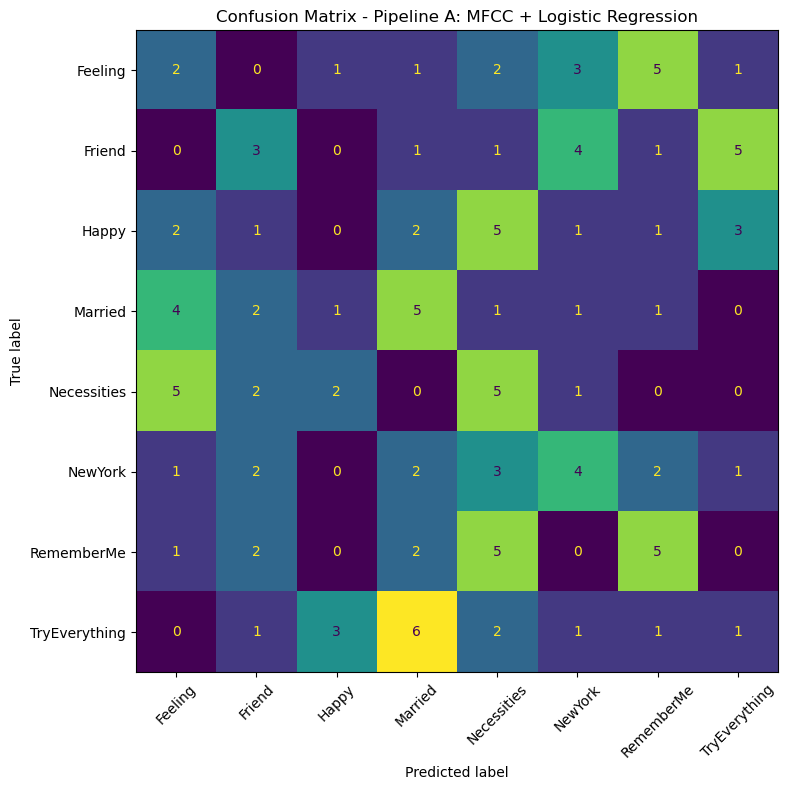

In [ ]:
results = []

def evaluate_pipeline(name, model, X_train, X_val, y_train, y_val, label_encoder, show_cm=True):
    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    bal_acc = balanced_accuracy_score(y_val, pred)

    results.append({
        "Pipeline": name,
        "Accuracy": acc,
        "Balanced Accuracy": bal_acc
    })

    print(f"=== {name} ===")
    print("Accuracy:", round(acc, 4))
    print("Balanced Accuracy:", round(bal_acc, 4))
    print()
    print(classification_report(y_val, pred, target_names=label_encoder.classes_))

    if show_cm:
        fig, ax = plt.subplots(figsize=(8, 8))
        ConfusionMatrixDisplay.from_predictions(
            y_val,
            pred,
            display_labels=label_encoder.classes_,
            xticks_rotation=45,
            ax=ax,
            colorbar=False
        )
        plt.title(f"Confusion Matrix - {name}")
        plt.tight_layout()
        plt.show()

    return model, pred

pipeline_a = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000))
])

model_a, pred_a = evaluate_pipeline(
    "Pipeline A: MFCC + Logistic Regression",
    pipeline_a,
    X_train_mfcc,
    X_val_mfcc,
    y_train,
    y_val,
    label_encoder
)

### 6.2 Pipeline B: MFCC + SVM Results



=== Pipeline B: MFCC + SVM ===
Accuracy: 0.2167
Balanced Accuracy: 0.2167

               precision    recall  f1-score   support

      Feeling       0.12      0.07      0.09        15
       Friend       0.18      0.13      0.15        15
        Happy       0.00      0.00      0.00        15
      Married       0.33      0.47      0.39        15
  Necessities       0.21      0.27      0.24        15
      NewYork       0.19      0.20      0.19        15
   RememberMe       0.27      0.53      0.36        15
TryEverything       0.10      0.07      0.08        15

     accuracy                           0.22       120
    macro avg       0.18      0.22      0.19       120
 weighted avg       0.18      0.22      0.19       120



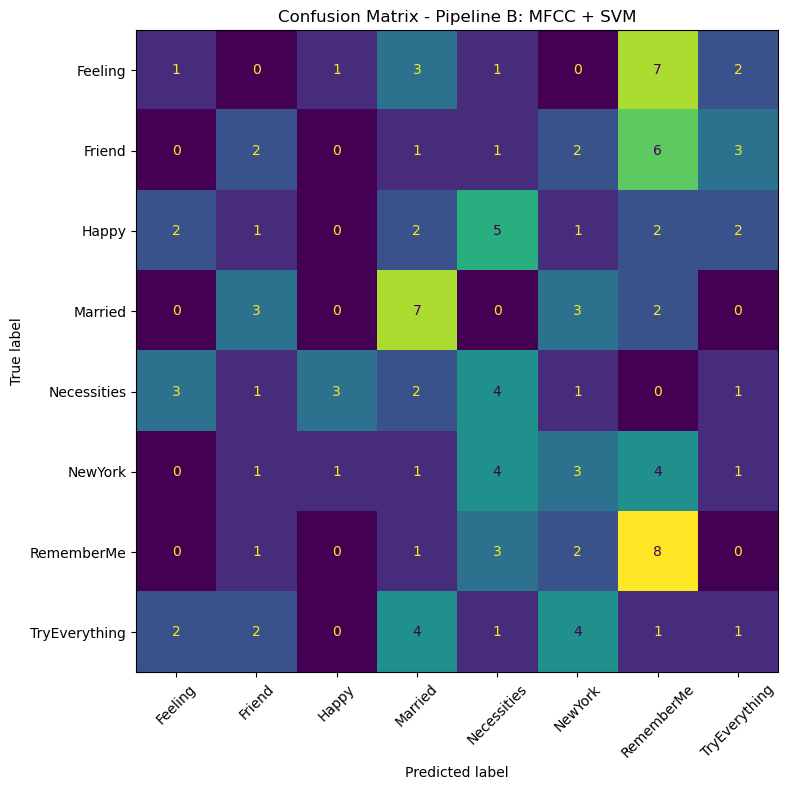

In [ ]:
pipeline_b = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True))
])

model_b, pred_b = evaluate_pipeline(
    "Pipeline B: MFCC + SVM",
    pipeline_b,
    X_train_mfcc,
    X_val_mfcc,
    y_train,
    y_val,
    label_encoder
)

### 6.3 Pipeline C: Chroma + SVM Results



=== Pipeline C: Chroma + SVM ===
Accuracy: 0.325
Balanced Accuracy: 0.325

               precision    recall  f1-score   support

      Feeling       0.33      0.27      0.30        15
       Friend       0.47      0.53      0.50        15
        Happy       0.21      0.27      0.24        15
      Married       0.45      0.33      0.38        15
  Necessities       0.33      0.47      0.39        15
      NewYork       0.33      0.27      0.30        15
   RememberMe       0.33      0.20      0.25        15
TryEverything       0.21      0.27      0.24        15

     accuracy                           0.33       120
    macro avg       0.33      0.33      0.32       120
 weighted avg       0.33      0.33      0.32       120



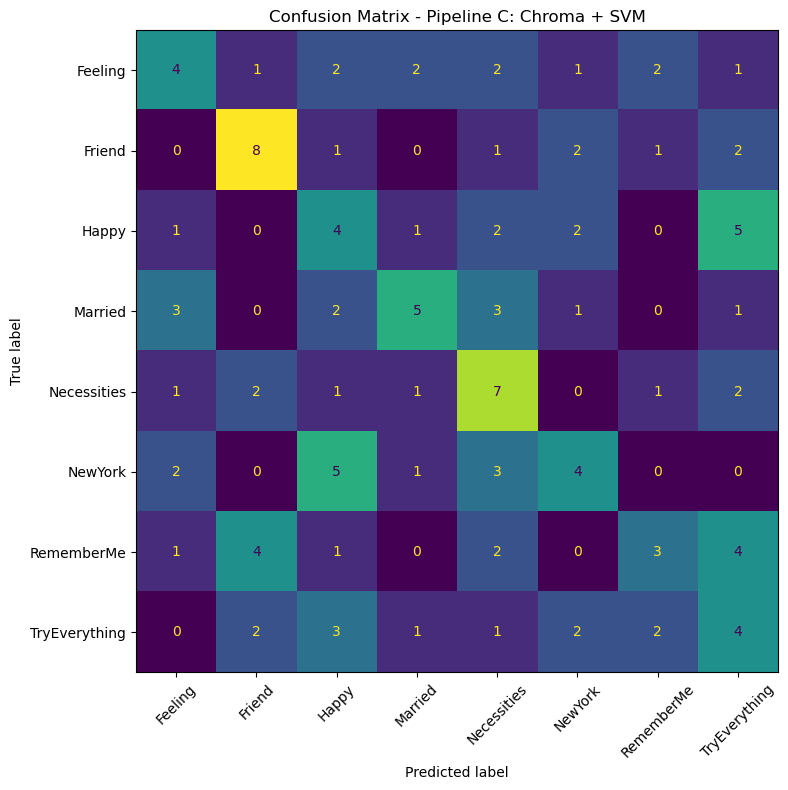

In [ ]:
pipeline_c = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True))
])

model_c, pred_c = evaluate_pipeline(
    "Pipeline C: Chroma + SVM",
    pipeline_c,
    X_train_chroma,
    X_val_chroma,
    y_train,
    y_val,
    label_encoder
)

# 7 Conclusions

Your conclusions, suggestions for improvements, etc should go here.

# Answer

This project focused on a multi class classification in which the input is the raw audio from the 400 sample data set and the output is a prediction of the songs label. I found this problem challenging but intriguing as I was able to explore and implement different machine learning models.

The results show that we where able to extract key information from the features as with the use of Chroma captured patterns in the pitch and MFCC captured the spectral aspect. However despite this approach it is evident from the results the model did not perform well. Pipeline A and B presently an average of 21% to 22% correct prediction rates. Where as in pipeline 3 with the use of Chroma and SVM the performance in the model increased with a 33% prediction rate. It is also evident from the confusion matrix I preformed that pipeline performed significantly in identifying which labels where being misclassified with one another.

One improvement is to re evaluate the models used in the pipeline. For example incorporating Mel Spectrogram would give us a visual representation of the sample and gives us a more enhanced frequency. Also considering a combined feature could positively impact the performance during the transformation stage. A common limitation in my approach was cause by the sample size I used, I could have higher generalisation in my data if I used the 800 dataset instead of the 400 dataset.

# 8 References

Acknowledge others here (books, papers, repositories, libraries, tools)

Libraries:
Librosa, Sklearn, Numpy, Pandas, Matplotlib, os, Zipfile, Pathlib, Warnings.

Dataset: MLEnd Hums and Whistles II 400 sample Dataset, from ECS7020P project.

References:

Bishop, C.M. and Nasrabadi, N.M., 2006. Pattern recognition and machine learning (Vol. 4, No. 4, p. 738). New York: springer. Available at: https://www.microsoft.com/en-us/research/wp-content/uploads/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf (Accessed 8 March 2026)

Cortes, C. and Vapnik, V. (1995). Support-vector networks. Machine Learning, 20(3), pp.273–297. Available at :https://doi.org/10.1007/BF00994018 (Accessed 9 Apr. 2026).

Dannenberg, R.B., Birmingham, W.P., Tzanetakis, G., Meek, C., Hu, N. and Pardo, B. (2004). The MUSART Testbed for QuerybyHumming Evaluation. Computer Music Journal, 28(2), pp.34–48. Available at: https://www.jstor.org/stable/3681825 (Accessed 8 Mar. 2026).

Davis, S. and Mermelstein, P. (1980). Comparison of parametric representations for monosyllabic word recognition in continuously spoken sentences. IEEE Transactions on Acoustics, Speech, and Signal Processing, 28(4), pp.357–366. Available at: https://doi.org/10.1109/tassp.1980.1163420. (Accessed 9 Apr. 2026).

Dhurandhar, A. (2013). Auto-correlation Dependent Bounds for Relational Data. [online] Available at: https://snap.stanford.edu/mlg2013/submissions/mlg2013_submission_1.pdf (Accessed 8 Apr. 2026).

Giannakopoulos, T., Aggelos Pikrakis and Theodoridis, S. (2007). A Multi-Class Audio Classification Method With Respect To Violent Content In Movies Using Bayesian Networks. A Multi-Class Audio Classification Method With Respect To Violent Content In Movies Using Bayesian Networks, pp.90–93 Available at::https://doi.org/10.1109/mmsp.2007.4412825. (Accessed 8 Apr. 2026)

McFee, B., Raffel, C., Liang, D., Ellis, D.P., McVicar, M., Battenberg, E. and Nieto, O., 2015. librosa: Audio and music signal analysis in python. SciPy, 2015(18-24), p.7. Available at: https://d1wqtxts1xzle7.cloudfront.net/40296500/librosa-libre.pdf?1448292194=&response-content-disposition=inline%3B+filename%3Dlibrosa_Audio_and_Music_Signal_Analysis.pdf&Expires=1776221311&Signature=UxnFYtbsXgEAt1hB6kfZLGsdOGQUJkhPMrdkiEdtirud-lkoo6NToNF58YCQsW03HTFooNZ7iuO~BXK1~E6yld0GWYgYLveBkAkU9EUl8lcbuiecxfxSZW9X8nXgNKIqkYQSZZglOMVrzoLZg5Hqa6JJQ-CQlTtci~CEXfrKcFZhr9nroUC2ut7Z6y2gBB5x5LhSMNPHhh5nuTXj-lLzahnOaaLpQvkMSsvY6k5VtzQdHj8GPE0Ueb732x8WBReLVH80GjHLZJAa8xGNN7lmNjyUSOrs6F5j~LQvI8VwklQkxwwKg-XGfWYNvPa--ISLLhIXJG0D72wGBlBCPNoRxA__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA (Accessed 8 Apr. 2026)

Müller, M. and Ewert, S. (2011). CHROMA TOOLBOX: MATLAB IMPLEMENTATIONS FOR EXTRACTING VARIANTS OF CHROMA-BASED AUDIO FEATURES. [online] Available at: https://sebewert.github.io/publications_pdf/2011_MuellerEwert_ChromaToolbox_ISMIR.pdf (Accessed 9 Apr. 2026).

Pierre-Olivier Côté, Amin Nikanjam, Ahmed, N., Humeniuk, D. and Foutse Khomh (2024). Data cleaning and machine learning: a systematic literature review. Automated software engineering, 31(2). Available at: :https://doi.org/10.1007/s10515-024-00453-w. (Accessed 8 Mar. 2026).

Xie, B., Bian, W., Tao, D. and Chordia, P. (2011). MUSIC TAGGING WITH REGULARIZED LOGISTIC REGRESSION. [online] Available at: https://archives.ismir.net/ismir2011/paper/000114.pdf (Accessed 9 Apr. 2026).